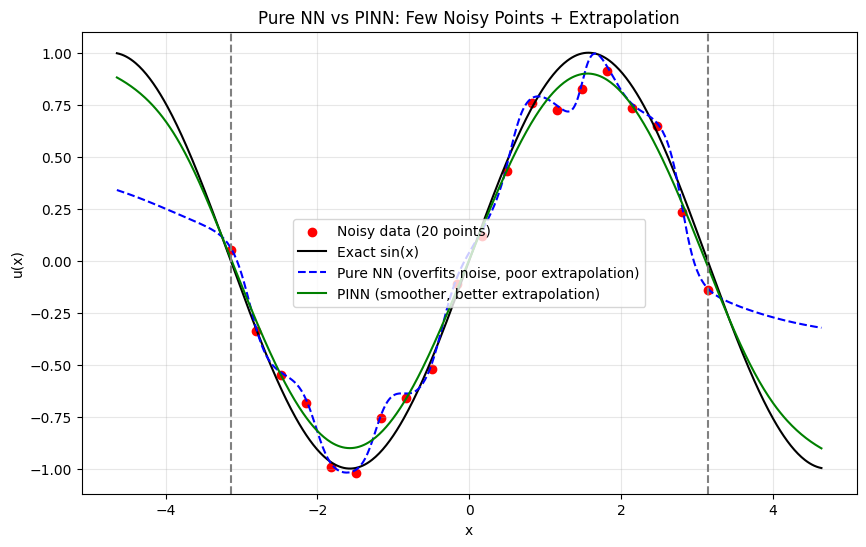

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Noisy data (20 points)
np.random.seed(42)
x_data = np.linspace(-np.pi, np.pi, 20)
y_data = np.sin(x_data) + 0.1 * np.random.randn(20)

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)
        )
    def forward(self, x):
        return self.net(x)

# Train pure data-driven NN
model_data = SimpleNN()
opt_data = torch.optim.Adam(model_data.parameters(), lr=0.01)
x_torch = torch.tensor(x_data.reshape(-1,1), dtype=torch.float32)
y_torch = torch.tensor(y_data.reshape(-1,1), dtype=torch.float32)

for epoch in range(5000):

    pred = model_data(x_torch)
    loss = nn.MSELoss()(pred, y_torch)
    if epoch % 500 == 0:
        with torch.no_grad():
            print(f"Epoch {epoch}, Data Loss: {loss.item():.4f}")
    opt_data.zero_grad()
    loss.backward()
    opt_data.step()

# Train PINN with physics: enforce u_xx + u ≈ 0
model_pinn = SimpleNN()
opt_pinn = torch.optim.Adam(model_pinn.parameters(), lr=0.01)
x_colloc = torch.linspace(-np.pi, np.pi, 300).reshape(-1,1)  # collocation points

for epoch in range(5000):
    # Data loss
    pred_data = model_pinn(x_torch)
    loss_data = nn.MSELoss()(pred_data, y_torch)
    
    # Physics loss
    x_colloc.requires_grad_(True)
    u = model_pinn(x_colloc)
    u_x = torch.autograd.grad(u, x_colloc, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_colloc, torch.ones_like(u_x), create_graph=True)[0]
    residual = u_xx + u  # for solutions like sin(x), u_xx + u = 0
    loss_phys = torch.mean(residual**2)
    
    loss = loss_data + 20 * loss_phys  # weight physics
    opt_pinn.zero_grad()
    loss.backward()
    opt_pinn.step()

# Plot with extrapolation
x_test = np.linspace(-np.pi-1.5, np.pi+1.5, 600)
x_test_torch = torch.tensor(x_test.reshape(-1,1), dtype=torch.float32)

with torch.no_grad():
    y_exact = np.sin(x_test)
    y_data_nn = model_data(x_test_torch).numpy().flatten()
    y_pinn = model_pinn(x_test_torch).numpy().flatten()

plt.figure(figsize=(10,6))
plt.scatter(x_data, y_data, color='red', label='Noisy data (20 points)')
plt.plot(x_test, y_exact, 'k-', label='Exact sin(x)')
plt.plot(x_test, y_data_nn, 'b--', label='Pure NN (overfits noise, poor extrapolation)')
plt.plot(x_test, y_pinn, 'g-', label='PINN (smoother, better extrapolation)')
plt.axvline(-np.pi, color='gray', linestyle='--')
plt.axvline(np.pi, color='gray', linestyle='--')
plt.legend()
plt.title('Pure NN vs PINN: Few Noisy Points + Extrapolation')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.grid(alpha=0.3)
plt.show()